# Financial Research Agent

This notebook tests the financial agent with tools. The workflow is:

1. The model plans which tools to use.
2. Python executes those tools.
3. The model receives the tool results and writes the final analysis.

The key difference is that `SYSTEM_PROMPT` is used in the final model call, while `TOOL_PLANNING_PROMPT` is used in the planning call.

## Dependencies

From the `agents/financial_research_agent` folder, install dependencies with Poetry if they are not installed yet:

```bash
python -m poetry install
```

You also need Ollama running and the local model available, for example `qwen2.5:3b`.

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "Notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

PROJECT_ROOT

WindowsPath('c:/Users/inter/OneDrive - Universidad Externado de Colombia/Cuarto Semestre/Seminario Modelos Multiagentes/Clase 3')

In [2]:
from agents.agent import FinancialResearchAgent
from agents.prompts import SYSTEM_PROMPT, TOOL_PLANNING_PROMPT

print("SYSTEM_PROMPT:\n")
print(SYSTEM_PROMPT)
print("\n" + "=" * 80 + "\n")
print("TOOL_PLANNING_PROMPT:\n")
print(TOOL_PLANNING_PROMPT)

SYSTEM_PROMPT:

You are a senior financial research analyst working at an investment firm.

Your job is to help analysts answer questions about stocks, ETFs, performance,
volatility, drawdowns, trends and risk using only the data returned by tools.

Rules:
1. Do not invent prices, dates, tickers or metrics.
2. Separate factual findings from interpretation.
3. Explain risk in plain business language.
4. Mention uncertainty and data limitations explicitly.
5. Do not provide personalized investment advice.
6. Keep recommendations framed as analytical next steps, not buy/sell orders.
7. Use markdown with concise sections.


TOOL_PLANNING_PROMPT:

You are a tool planning assistant for a financial research agent.

Your only job is to decide which tools should be executed to answer the user's
financial analysis question.

Return only valid JSON. Do not include markdown, explanations or comments.
The JSON must follow this schema:

{
  "tools": [
    {
      "name": "tool_name",
      "argument

## Create the agent

The agent receives a local Ollama model and builds a `ToolRegistry`. The registry contains the executable tools: download data, compute metrics, create charts, and compare assets.

In [3]:
agent = FinancialResearchAgent(model_name="qwen2.5:3b")
agent.tool_registry.describe_tools()

[{'name': 'get_stock_data',
  'description': 'Download recent historical OHLCV data from Yahoo Finance. Arguments: ticker (string), period (string, optional).'},
 {'name': 'compute_stock_metrics',
  'description': 'Compute return, volatility and drawdown metrics for one stock or ETF. Arguments: ticker (string), period (string, optional).'},
 {'name': 'plot_price_history',
  'description': 'Generate a price history chart for one stock or ETF. Arguments: ticker (string), period (string, optional).'},
 {'name': 'compare_stocks',
  'description': 'Compare multiple stocks or ETFs over the same period. Arguments: tickers (list of strings), period (string, optional).'}]

## Test question

The question mentions multiple tickers and asks to compare performance and risk. This should trigger `compare_stocks` and, depending on the model plan, may also trigger individual metrics.

In [4]:
user_question = "Compare the performance, volatility, and drawdown of AAPL, MSFT, and SPY over the last year. Generate a comparative chart."
user_question

'Compare the performance, volatility, and drawdown of AAPL, MSFT, and SPY over the last year. Generate a comparative chart.'

## Step 1: tool planning

This cell internally calls Ollama with:

```python
messages=[
    {"role": "system", "content": TOOL_PLANNING_PROMPT},
    {"role": "user", "content": build_tool_planning_prompt(...)},
]
```

The result must be valid JSON.

In [5]:
tool_plan = agent._plan_tools(user_question)
tool_plan

{'tools': [{'name': 'get_stock_data',
   'arguments': {'ticker': 'AAPL', 'period': '1y'}},
  {'name': 'compute_stock_metrics',
   'arguments': {'ticker': 'AAPL', 'period': '1y'}},
  {'name': 'get_stock_data', 'arguments': {'ticker': 'MSFT', 'period': '1y'}},
  {'name': 'compute_stock_metrics',
   'arguments': {'ticker': 'MSFT', 'period': '1y'}},
  {'name': 'get_stock_data', 'arguments': {'ticker': 'SPY', 'period': '1y'}},
  {'name': 'compute_stock_metrics',
   'arguments': {'ticker': 'SPY', 'period': '1y'}},
  {'name': 'compare_stocks',
   'arguments': {'tickers': ['AAPL', 'MSFT', 'SPY'], 'period': '1y'}}]}

## Step 2: execute tools

At this point the LLM is no longer deciding. Python executes exactly the tools included in the previous JSON.

In [6]:
tool_results = agent._execute_tool_plan(tool_plan)
tool_results

{'step_1_get_stock_data': {'ticker': 'AAPL',
  'period': '1y',
  'rows': 251,
  'start_date': '2025-05-30',
  'end_date': '2026-05-29',
  'last_close': 312.06,
  'last_rows': [{('Date', ''): Timestamp('2026-05-22 00:00:00'),
    ('Close', 'AAPL'): 308.82000732421875,
    ('High', 'AAPL'): 311.3999938964844,
    ('Low', 'AAPL'): 305.8399963378906,
    ('Open', 'AAPL'): 306.1199951171875,
    ('Volume', 'AAPL'): 43670200},
   {('Date', ''): Timestamp('2026-05-26 00:00:00'),
    ('Close', 'AAPL'): 308.3299865722656,
    ('High', 'AAPL'): 311.82000732421875,
    ('Low', 'AAPL'): 307.6700134277344,
    ('Open', 'AAPL'): 309.55999755859375,
    ('Volume', 'AAPL'): 48000500},
   {('Date', ''): Timestamp('2026-05-27 00:00:00'),
    ('Close', 'AAPL'): 310.8500061035156,
    ('High', 'AAPL'): 313.260009765625,
    ('Low', 'AAPL'): 308.29998779296875,
    ('Open', 'AAPL'): 308.3299865722656,
    ('Volume', 'AAPL'): 50430900},
   {('Date', ''): Timestamp('2026-05-28 00:00:00'),
    ('Close', 'AAPL

## Step 3: final answer

This is the call where the financial analyst `SYSTEM_PROMPT` is used:

```python
messages=[
    {"role": "system", "content": SYSTEM_PROMPT},
    {"role": "user", "content": final_prompt},
]
```

The model does not query Yahoo Finance directly; it interprets the results already returned by the tools.

In [8]:
response = agent.analyze(user_question)
print(response.content)

# Comparative Analysis of AAPL, MSFT, and SPY Over the Last Year

## Executive Summary
This analysis compares the performance, volatility, and drawdowns of Apple (AAPL), Microsoft (MSFT), and the S&P 500 ETF (SPY) over a one-year period. The results indicate significant differences in these metrics among the three stocks/ETFs, with AAPL showing high returns but also high volatility and substantial drawdowns, while SPY exhibits more stable performance with lower risk.

## Factual Findings From the Tools

### AAPL (Apple)
- **Last Close Price**: $312.06
- **Cumulative Return (%)**: 55.99%
- **Annualized Volatility (%)**: 22.08%
- **Max Drawdown (%)**: -13.8%

### MSFT (Microsoft)
- **Last Close Price**: $450.24
- **Cumulative Return (%)**: -1.42%
- **Annualized Volatility (%)**: 24.56%
- **Max Drawdown (%)**: -33.91%

### SPY (S&P 500 ETF)
- **Last Close Price**: $756.48
- **Cumulative Return (%)**: 29.82%
- **Annualized Volatility (%)**: 11.86%
- **Max Drawdown (%)**: -8.88%

## Risk an

In [9]:
response.tool_plan

{'tools': [{'name': 'compare_stocks',
   'arguments': {'tickers': ['AAPL', 'MSFT', 'SPY'], 'period': '1y'}}]}

In [10]:
response.tool_results

{'step_1_compare_stocks': {'tickers': ['AAPL', 'MSFT', 'SPY'],
  'period': '1y',
  'metrics': [{'ticker': 'AAPL',
    'last_close': 312.06,
    'cumulative_return_pct': 55.99,
    'annualized_volatility_pct': 22.08,
    'max_drawdown_pct': -13.8},
   {'ticker': 'MSFT',
    'last_close': 450.24,
    'cumulative_return_pct': -1.42,
    'annualized_volatility_pct': 24.56,
    'max_drawdown_pct': -33.91},
   {'ticker': 'SPY',
    'last_close': 756.48,
    'cumulative_return_pct': 29.82,
    'annualized_volatility_pct': 11.86,
    'max_drawdown_pct': -8.88}],
  'chart_path': 'C:\\Users\\inter\\OneDrive - Universidad Externado de Colombia\\Cuarto Semestre\\Seminario Modelos Multiagentes\\Clase 3\\agents\\outputs\\aapl_msft_spy_1y_comparison.png',
  'start_date': '2025-05-30',
  'end_date': '2026-05-29'}}

## Display generated chart

If the plan included a charting tool, the PNG path is stored inside `tool_results`.

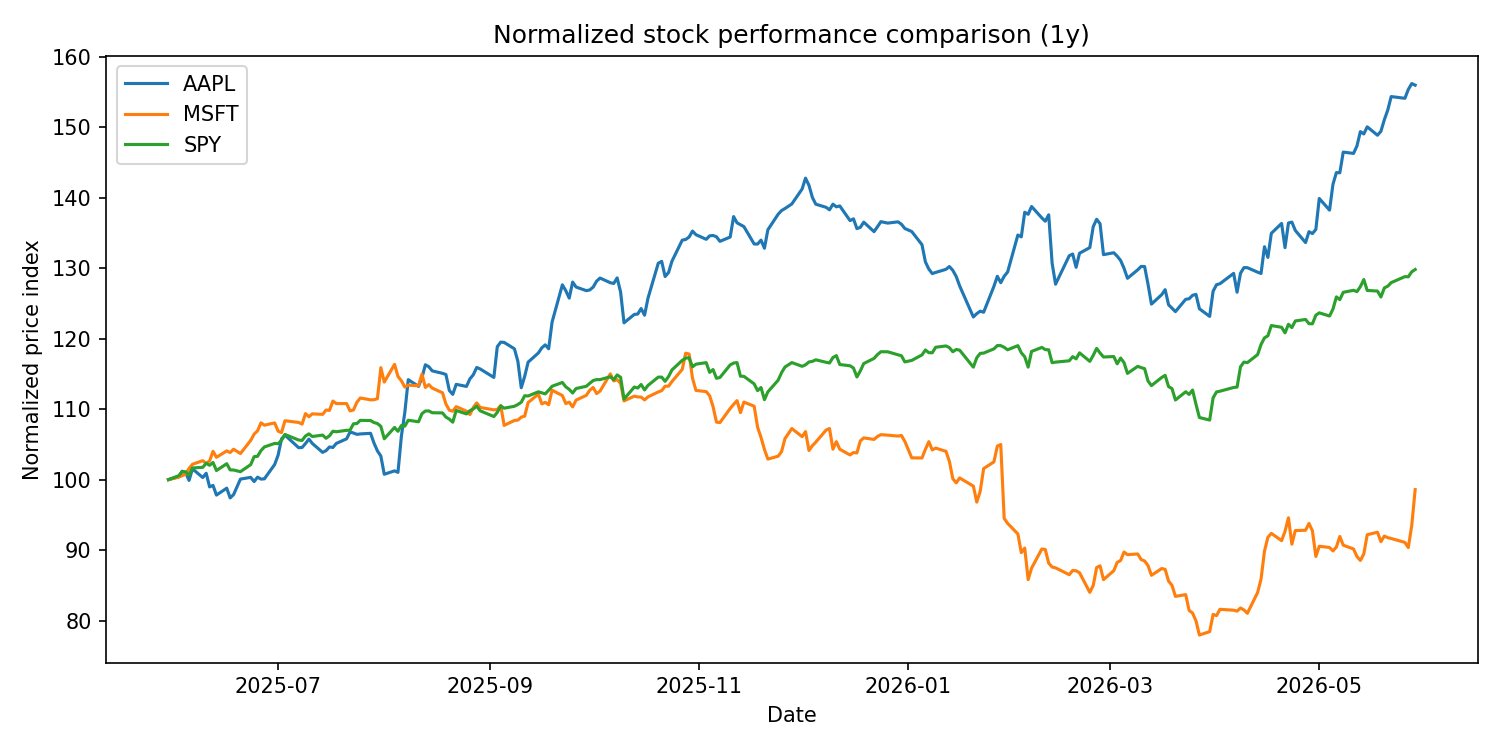

In [11]:
from IPython.display import Image, display

for result in response.tool_results.values():
    chart_path = result.get("chart_path") if isinstance(result, dict) else None
    if chart_path:
        display(Image(filename=chart_path))